# Phase 1.5 §04 — HAR-RV 모델 자체 검증 (`04_har_rv_evaluation.ipynb`)

> **목적**: §03 이 "여러 모델 비교" 였다면, §04 는 **HAR-RV 모델 자체의 내부 건강성·신뢰도** 학술 표준 검증.
>
> §03 에서 HAR-RV 가 "모든 모델 중 1위" 임을 확인했지만, "그 1위가 신뢰할 만한가?" 는 별개 질문.

## 본 노트북의 6가지 핵심 질문

| § | 질문 | 학술 도구 |
|---|---|---|
| §2 | "fold 가 바뀌어도 모델이 안정적인가?" | β 분포 (90 fold) + 시계열 추이 |
| §3 | "잔차가 통계 가정 (정규·독립·등분산) 을 만족하는가?" | JB · DW · BP 검정 |
| §4 | "예측이 unbiased 한가?" | Mincer-Zarnowitz Wald 검정 |
| §5 | "다른 모델 대비 차이가 통계적으로 유의한가?" | Diebold-Mariano (1995) |
| §6 | "체제 변화 (COVID, 긴축) 에서 어떻게 반응했나?" | 기간 분리 RMSE + 잔차 시계열 |
| §7 | "HAR 의 long-memory 모방 능력은?" | 시뮬레이션 ACF vs 실제 ACF |

## 본 노트북 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 부트스트랩 + LSTM/베이스라인 결과 로드 + HAR 90 fold 재계산 |
| §2 | 계수 안정성 분석 (4 sub-section) |
| §3 | 잔차 진단 (5 sub-section) |
| §4 | Mincer-Zarnowitz 깊이 분석 (3 sub-section) |
| §5 | Diebold-Mariano 검정 (3 sub-section) |
| §6 | 체제 변화 분석 (3 sub-section) |
| §7 | Long-memory 모방 검증 (3 sub-section) |
| §8 | 종합 결론 + `har_rv_diagnostics.md` 자동 생성 |

## 추가 라이브러리

- `statsmodels.api` (OLS, Wald 검정, JB, DW, BP)
- `scipy.stats` (Q-Q plot, 정규성, 카이제곱)


## §1. 환경 부트스트랩 + 데이터 로드 + HAR 90 fold 재계산


In [1]:
import sys
import json
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

from scripts.setup import bootstrap, BASE_DIR, RAW_DATA_DIR, RESULTS_DIR
font_used = bootstrap()
print(f"BASE_DIR     = {BASE_DIR}")
print(f"RESULTS_DIR  = {RESULTS_DIR}")

# §03 의 LSTM v1, v2 결과 재활용 (DM 검정 등에 필요)
V1_DIR = RESULTS_DIR / 'volatility_lstm'
V2_DIR = RESULTS_DIR / 'volatility_lstm_har3ch'
lstm_v1 = {}; lstm_v2 = {}
for tk in ('SPY', 'QQQ'):
    with open(V1_DIR / f'{tk}_metrics.json', 'r', encoding='utf-8') as f:
        lstm_v1[tk] = json.load(f)
    with open(V2_DIR / f'{tk}_metrics.json', 'r', encoding='utf-8') as f:
        lstm_v2[tk] = json.load(f)
print(f'LSTM v1, v2 fold predictions 로드 완료')


  Phase 1 — 환경 부트스트랩 완료
  한글 폰트  : Malgun Gothic
  시드       : 42
  결과 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results
BASE_DIR     = C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
RESULTS_DIR  = C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results
LSTM v1, v2 fold predictions 로드 완료


In [2]:
# 데이터 로드 + Walk-Forward fold 재구성 + HAR 90 fold 재계산
import pandas as pd
import numpy as np
from scripts.targets_volatility import build_daily_target_logrv_21d
from scripts.dataset import walk_forward_folds
from scripts.baselines_volatility import (
    fit_har_rv, predict_ewma, predict_naive, predict_train_mean,
)

ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2025-12-31'
WINDOW = 21


def load_ticker_full(ticker: str) -> pd.DataFrame:
    csv_path = RAW_DATA_DIR / f'{ticker}.csv'
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True).sort_index()
    df['log_ret'] = np.log(df['Adj Close']).diff()
    return df


analysis_dict = {}
for tk in ('SPY', 'QQQ'):
    raw = load_ticker_full(tk)
    df = raw.loc[ANALYSIS_START:ANALYSIS_END].copy()
    df['target_logrv'] = build_daily_target_logrv_21d(df['Adj Close'], window=WINDOW)
    df['rv_trailing'] = df['log_ret'].rolling(WINDOW).std(ddof=1)
    analysis_dict[tk] = df

# Walk-Forward 파라미터 (LSTM 학습 시 동일)
wf = lstm_v1['SPY']['hyperparams']['walk_forward']
IS_LEN  = wf['IS']
PURGE   = wf['purge']
EMBARGO = wf['embargo']
OOS_LEN = wf['OOS']
STEP    = wf['step']
N_VALID = min(int(analysis_dict[tk]['target_logrv'].notna().sum()) for tk in ('SPY', 'QQQ'))
folds_list = walk_forward_folds(
    n=N_VALID, is_len=IS_LEN, purge=PURGE, emb=EMBARGO, oos_len=OOS_LEN, step=STEP,
)
N_FOLDS = len(folds_list)
print(f'fold {N_FOLDS} 개 재구성 완료')


# HAR 90 fold 재계산 + 부수 베이스라인 재계산
def regenerate_baselines(ticker: str, df: pd.DataFrame, folds: list) -> dict:
    out = {}
    for k, (tr_idx, te_idx) in enumerate(folds):
        har_pred, har_coefs = fit_har_rv(
            log_ret=df['log_ret'], train_idx=tr_idx, test_idx=te_idx, horizon=WINDOW,
        )
        ewma_pred = predict_ewma(
            log_ret=df['log_ret'], train_idx=tr_idx, test_idx=te_idx, horizon=WINDOW, lam=0.94,
        )
        naive_pred = predict_naive(
            rv_trailing=df['rv_trailing'], train_idx=tr_idx, test_idx=te_idx,
        )
        tm_pred = predict_train_mean(
            target=df['target_logrv'], train_idx=tr_idx, test_idx=te_idx,
        )
        y_true = df['target_logrv'].values[te_idx]
        out[k] = {
            'y_true': y_true,
            'har': har_pred, 'ewma': ewma_pred, 'naive': naive_pred, 'train_mean': tm_pred,
            'har_coefs': har_coefs,
            'test_idx': te_idx,
            'train_idx': tr_idx,
        }
    return out


baseline_dict = {}
for tk in ('SPY', 'QQQ'):
    baseline_dict[tk] = regenerate_baselines(tk, analysis_dict[tk], folds_list)
    print(f'[{tk}] 베이스라인 재계산 완료 ({N_FOLDS} fold)')


# HAR 90 fold 의 β 추출
def extract_har_betas(baseline_data: dict) -> pd.DataFrame:
    rows = []
    for k in range(N_FOLDS):
        c = baseline_data[k]['har_coefs']
        rows.append({
            'fold': k, 'beta_0': c['beta_0'],
            'beta_d': c['beta_d'], 'beta_w': c['beta_w'], 'beta_m': c['beta_m'],
            'beta_sum': c['beta_d'] + c['beta_w'] + c['beta_m'],
            'r2_train': c['r2_train'], 'n_train': c['n_train'],
        })
    return pd.DataFrame(rows)


betas_dict = {}
for tk in ('SPY', 'QQQ'):
    betas_dict[tk] = extract_har_betas(baseline_dict[tk])

print()
print('HAR β 90 fold 통계 요약 (SPY 기준)')
print(betas_dict['SPY'][['beta_0', 'beta_d', 'beta_w', 'beta_m', 'beta_sum', 'r2_train']].describe().round(4))


fold 90 개 재구성 완료
[SPY] 베이스라인 재계산 완료 (90 fold)


[QQQ] 베이스라인 재계산 완료 (90 fold)

HAR β 90 fold 통계 요약 (SPY 기준)
         beta_0    beta_d    beta_w    beta_m  beta_sum  r2_train
count 90.000000 90.000000 90.000000 90.000000 90.000000 90.000000
mean  -2.267200  0.005300  0.187300  0.331500  0.524100  0.306000
std    0.822000  0.011500  0.100200  0.201600  0.159600  0.143300
min   -4.814700 -0.014200  0.031200 -0.116700  0.010100  0.013000
25%   -2.641900 -0.001800  0.112500  0.185000  0.454800  0.205400
50%   -2.180300  0.002600  0.161300  0.283800  0.529000  0.302400
75%   -1.769800  0.011100  0.266800  0.498500  0.631900  0.393700
max   -0.807900  0.032200  0.400300  0.739800  0.824200  0.654400


## §2. 계수 안정성 분석 — fold 가 바뀌어도 β 가 일관된가?

### 학술 배경
> 좋은 모델의 첫 조건은 **계수 안정성**. fold 마다 β 가 크게 변한다면 모델 구조 자체가 시계열에 적합하지 않음.

### 4 sub-section
- §2.A. β 분포 박스플롯 (90 fold × 4 계수)
- §2.B. β 시계열 추이 (체제 변화 진단)
- §2.C. β 합 분포 + 학술 권고치 (0.7~1.0) 대비
- §2.D. β_d, β_w, β_m 상관행렬 (다중공선성 진단)


### §2.A. β 분포 박스플롯


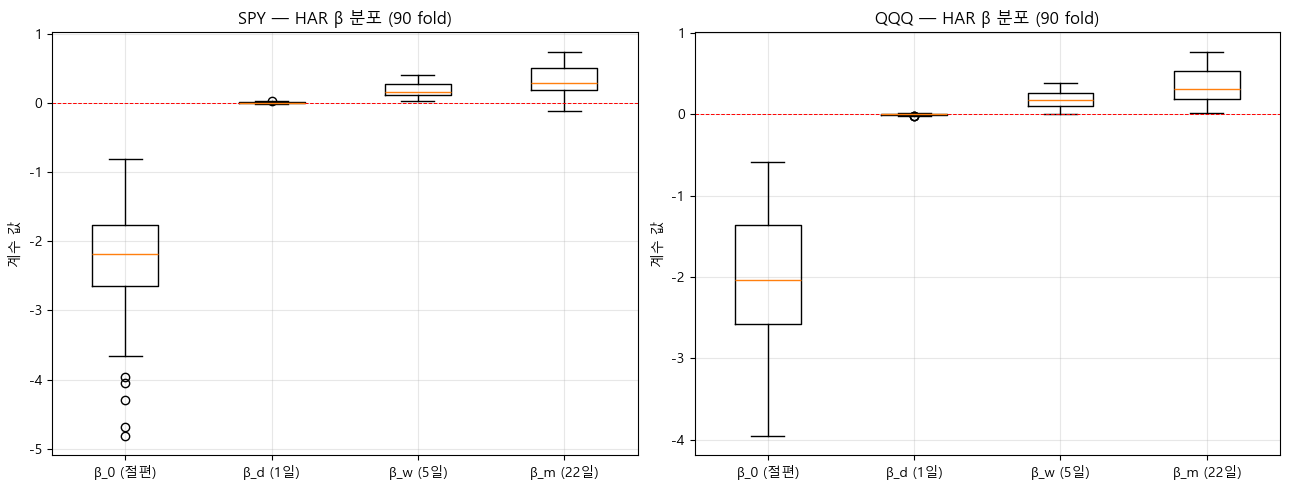



[SPY] β 분포 (mean ± std)
  beta_0  :  -2.2672 ± 0.8220  (min= -4.8147, max= -0.8079)
  beta_d  :  +0.0053 ± 0.0115  (min= -0.0142, max= +0.0322)
  beta_w  :  +0.1873 ± 0.1002  (min= +0.0312, max= +0.4003)
  beta_m  :  +0.3315 ± 0.2016  (min= -0.1167, max= +0.7398)

[QQQ] β 분포 (mean ± std)
  beta_0  :  -2.0223 ± 0.8191  (min= -3.9574, max= -0.5919)
  beta_d  :  +0.0004 ± 0.0096  (min= -0.0257, max= +0.0126)
  beta_w  :  +0.1823 ± 0.0968  (min= -0.0011, max= +0.3879)
  beta_m  :  +0.3660 ± 0.2115  (min= +0.0200, max= +0.7713)


In [3]:
import matplotlib.pyplot as plt

def plot_beta_boxplot(betas_dict):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, tk in zip(axes, ('SPY', 'QQQ')):
        df = betas_dict[tk]
        data = [df['beta_0'], df['beta_d'], df['beta_w'], df['beta_m']]
        labels = ['β_0 (절편)', 'β_d (1일)', 'β_w (5일)', 'β_m (22일)']
        ax.boxplot(data, tick_labels=labels)
        ax.axhline(0, color='red', lw=0.7, ls='--')
        ax.set_title(f'{tk} — HAR β 분포 (90 fold)')
        ax.set_ylabel('계수 값')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_beta_boxplot(betas_dict)

# 통계 요약
print()
for tk in ('SPY', 'QQQ'):
    df = betas_dict[tk]
    print(f'\n[{tk}] β 분포 (mean ± std)')
    for col in ['beta_0', 'beta_d', 'beta_w', 'beta_m']:
        print(f'  {col:<8}: {df[col].mean():>+8.4f} ± {df[col].std(ddof=1):>6.4f}  '
              f'(min={df[col].min():>+8.4f}, max={df[col].max():>+8.4f})')


### §2.B. β 시계열 추이 — 체제 변화 진단

각 fold 의 β 가 시간 (fold 인덱스 = 시간 순) 따라 어떻게 변하는지.
COVID 2020-03 (≈ fold 50), 2022 긴축 (≈ fold 70) 부근에서 변동 폭주 예상.


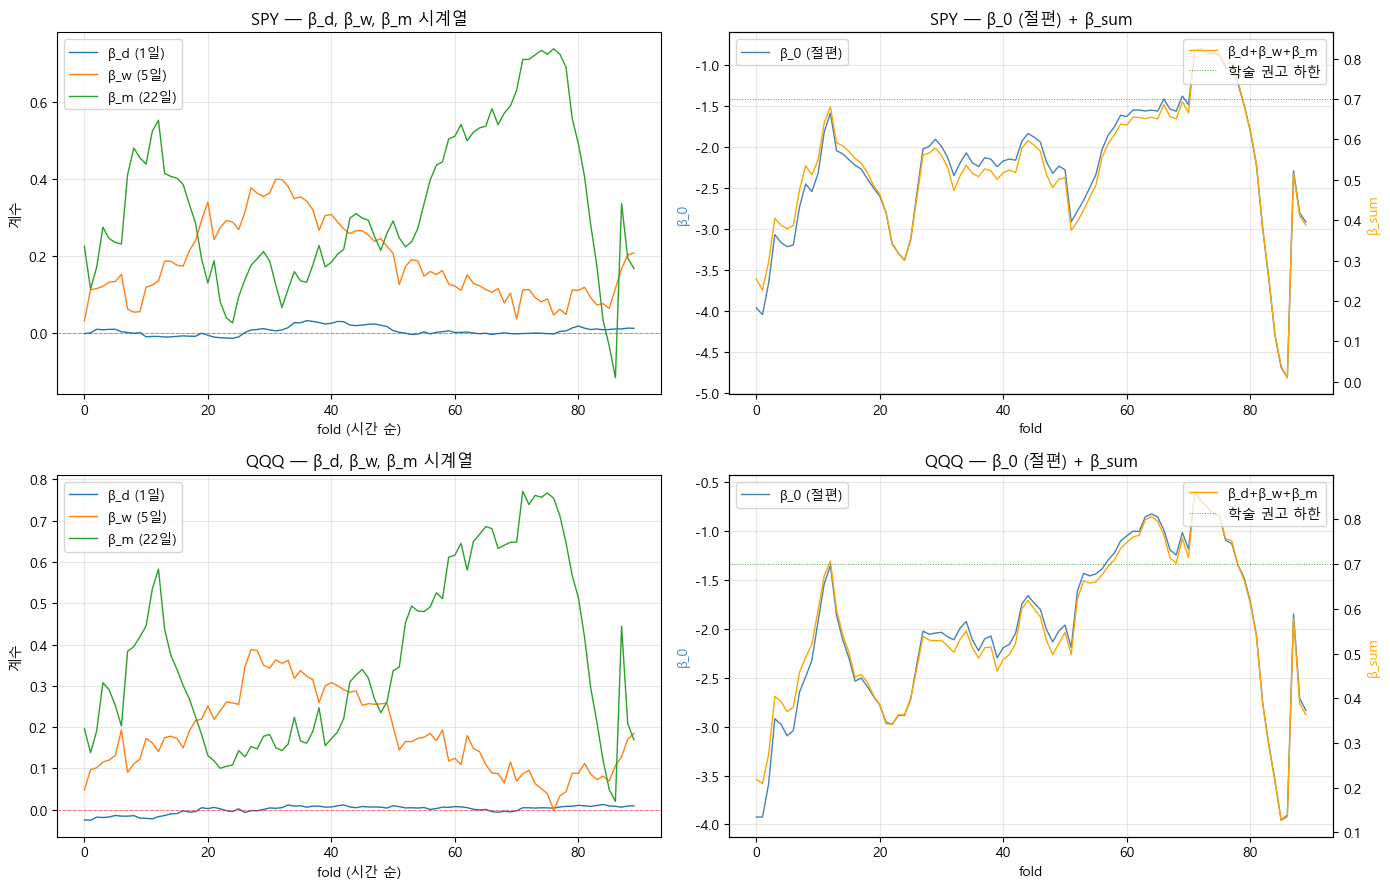

In [4]:
def plot_beta_timeseries(betas_dict):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for r, tk in enumerate(('SPY', 'QQQ')):
        df = betas_dict[tk]
        # 좌: β_d, β_w, β_m
        ax = axes[r, 0]
        ax.plot(df['fold'], df['beta_d'], label='β_d (1일)', lw=1.0)
        ax.plot(df['fold'], df['beta_w'], label='β_w (5일)', lw=1.0)
        ax.plot(df['fold'], df['beta_m'], label='β_m (22일)', lw=1.0)
        ax.axhline(0, color='red', lw=0.7, ls='--', alpha=0.5)
        ax.set_title(f'{tk} — β_d, β_w, β_m 시계열')
        ax.set_xlabel('fold (시간 순)')
        ax.set_ylabel('계수')
        ax.legend()
        ax.grid(alpha=0.3)
        # 우: β_0 + β_sum
        ax2 = axes[r, 1]
        ax2.plot(df['fold'], df['beta_0'], label='β_0 (절편)', lw=1.0, color='steelblue')
        ax2_t = ax2.twinx()
        ax2_t.plot(df['fold'], df['beta_sum'], label='β_d+β_w+β_m', lw=1.0, color='orange')
        ax2_t.axhline(0.7, color='green', lw=0.7, ls=':', alpha=0.7, label='학술 권고 하한')
        ax2.set_title(f'{tk} — β_0 (절편) + β_sum')
        ax2.set_xlabel('fold')
        ax2.set_ylabel('β_0', color='steelblue')
        ax2_t.set_ylabel('β_sum', color='orange')
        ax2.legend(loc='upper left')
        ax2_t.legend(loc='upper right')
        ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_beta_timeseries(betas_dict)


### §2.C. β 합 분포 + 학술 권고치 비교

> Corsi 2009 의 intraday 환경에서 β_d + β_w + β_m ≈ **0.7~1.0** 이 일반적.
> 본 프로젝트 (일별 데이터) 에선 variance proxy 의 noise 로 더 작을 것으로 예상.


β 합 (β_d + β_w + β_m) 분포 — 학술 권고 0.7~1.0 대비

[SPY]
  β_sum mean: +0.5241 (std=0.1596)
  β_sum > 0.7 (학술 하한) 비율 :   8.9%
  β_sum > 0.5 (관대 기준)  비율 :  66.7%
  Quantile (10%, 50%, 90%) : +0.3408, +0.5290, +0.6869

[QQQ]
  β_sum mean: +0.5486 (std=0.1689)
  β_sum > 0.7 (학술 하한) 비율 :  23.3%
  β_sum > 0.5 (관대 기준)  비율 :  63.3%
  Quantile (10%, 50%, 90%) : +0.3605, +0.5298, +0.7644


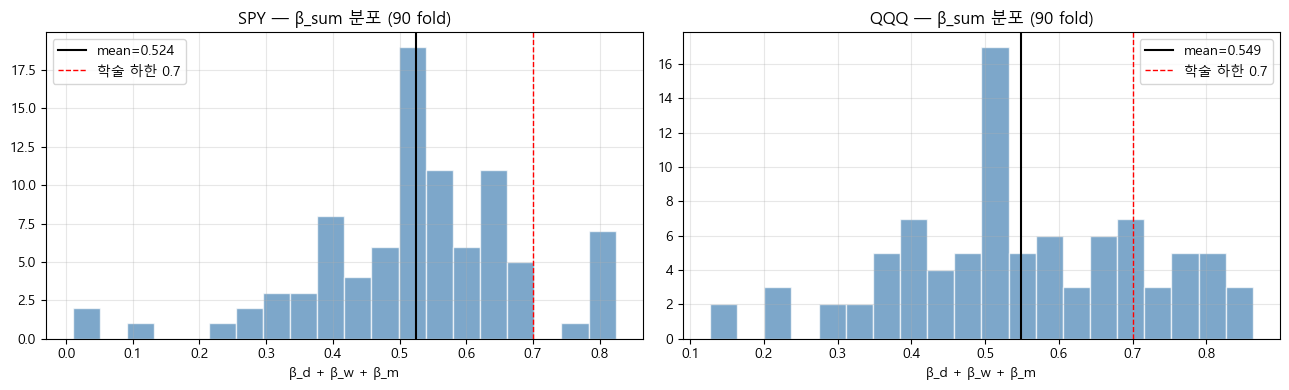

In [5]:
print('=' * 70)
print('β 합 (β_d + β_w + β_m) 분포 — 학술 권고 0.7~1.0 대비')
print('=' * 70)
for tk in ('SPY', 'QQQ'):
    df = betas_dict[tk]
    s = df['beta_sum']
    p_above_07 = (s > 0.7).mean() * 100
    p_above_05 = (s > 0.5).mean() * 100
    print(f'\n[{tk}]')
    print(f'  β_sum mean: {s.mean():+.4f} (std={s.std(ddof=1):.4f})')
    print(f'  β_sum > 0.7 (학술 하한) 비율 : {p_above_07:>5.1f}%')
    print(f'  β_sum > 0.5 (관대 기준)  비율 : {p_above_05:>5.1f}%')
    print(f'  Quantile (10%, 50%, 90%) : '
          f'{s.quantile(0.10):+.4f}, {s.quantile(0.50):+.4f}, {s.quantile(0.90):+.4f}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, tk in zip(axes, ('SPY', 'QQQ')):
    s = betas_dict[tk]['beta_sum']
    ax.hist(s, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(s.mean(), color='black', lw=1.5, label=f'mean={s.mean():.3f}')
    ax.axvline(0.7, color='red', lw=1.0, ls='--', label='학술 하한 0.7')
    ax.set_title(f'{tk} — β_sum 분포 (90 fold)')
    ax.set_xlabel('β_d + β_w + β_m')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### §2.D. β_d, β_w, β_m 상관행렬 — 다중공선성 진단

3개 features (RV_d, RV_w, RV_m) 가 서로 강하게 상관되어 OLS 추정이 불안정한지.
fold 마다 β 변동이 큰 이유 중 하나일 수 있음.


fold 간 β 끼리의 상관 (다중공선성 간접 진단)

[SPY]
          beta_d    beta_w    beta_m
beta_d  1.000000  0.364000 -0.299000
beta_w  0.364000  1.000000 -0.613000
beta_m -0.299000 -0.613000  1.000000

[QQQ]
          beta_d    beta_w    beta_m
beta_d  1.000000  0.213000 -0.017000
beta_w  0.213000  1.000000 -0.635000
beta_m -0.017000 -0.635000  1.000000


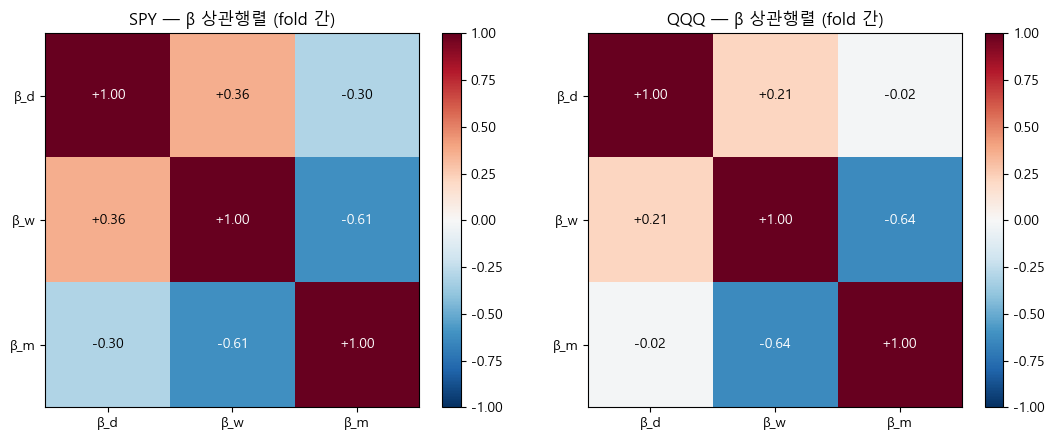

In [6]:
# 90 fold 에서 추정된 β 들끼리의 상관 (각 β 가 fold 간 어떻게 함께 움직이는가)
print('=' * 70)
print('fold 간 β 끼리의 상관 (다중공선성 간접 진단)')
print('=' * 70)
for tk in ('SPY', 'QQQ'):
    df = betas_dict[tk]
    corr = df[['beta_d', 'beta_w', 'beta_m']].corr()
    print(f'\n[{tk}]')
    print(corr.round(3).to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, tk in zip(axes, ('SPY', 'QQQ')):
    corr = betas_dict[tk][['beta_d', 'beta_w', 'beta_m']].corr().values
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{corr[i,j]:+.2f}', ha='center', va='center',
                    color='white' if abs(corr[i,j]) > 0.5 else 'black')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(['β_d', 'β_w', 'β_m'])
    ax.set_yticklabels(['β_d', 'β_w', 'β_m'])
    ax.set_title(f'{tk} — β 상관행렬 (fold 간)')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


## §3. 잔차 진단 — 통계 가정 (정규·독립·등분산) 충족 여부

### 학술 배경
OLS 의 통계적 추론 (계수 신뢰구간, p-value 등) 은 잔차가 다음을 만족할 때만 유효:
1. **정규성**: 잔차가 N(0, σ²) 분포 → Jarque-Bera 검정
2. **독립성**: 잔차가 자기상관 없음 → Durbin-Watson 검정
3. **등분산성**: 잔차의 분산이 일정 → Breusch-Pagan 검정

### 본 프로젝트의 잔차 정의
- 전체 OOS 1,890 샘플 (= 90 fold × 21일) 의 (y_true - har_pred) 시계열

### 5 sub-section
- §3.A. 잔차 시계열 (시간 추이)
- §3.B. 잔차 히스토그램 + Q-Q plot
- §3.C. Jarque-Bera 검정 (정규성)
- §3.D. Durbin-Watson 검정 (자기상관)
- §3.E. Breusch-Pagan 검정 (이분산성)


### §3.A. 잔차 시계열


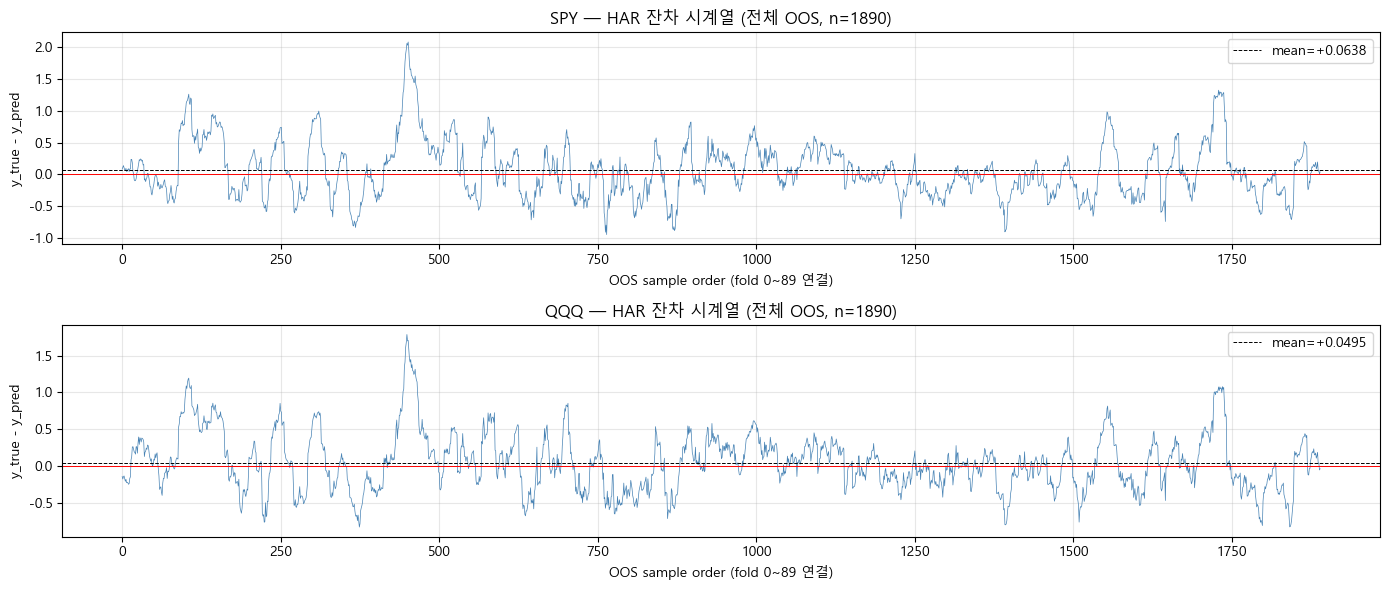

In [7]:
# 전체 OOS 잔차 시계열 (fold 0~89 시간순 연결)
def build_residual_series(baseline_data: dict) -> np.ndarray:
    residuals = []
    for k in range(N_FOLDS):
        y_true = baseline_data[k]['y_true']
        y_pred = baseline_data[k]['har']
        residuals.append(y_true - y_pred)
    return np.concatenate(residuals)


residual_dict = {tk: build_residual_series(baseline_dict[tk]) for tk in ('SPY', 'QQQ')}

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
for ax, tk in zip(axes, ('SPY', 'QQQ')):
    res = residual_dict[tk]
    ax.plot(res, lw=0.5, color='steelblue')
    ax.axhline(0, color='red', lw=0.7)
    ax.axhline(res.mean(), color='black', lw=0.7, ls='--', label=f'mean={res.mean():+.4f}')
    ax.set_title(f'{tk} — HAR 잔차 시계열 (전체 OOS, n={len(res)})')
    ax.set_xlabel('OOS sample order (fold 0~89 연결)')
    ax.set_ylabel('y_true - y_pred')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### §3.B. 잔차 히스토그램 + Q-Q plot

> **Q-Q plot 해석**: 점들이 빨간 선 (대각선) 에 일치하면 정규분포. 양 꼬리에서 벗어나면 fat-tail.


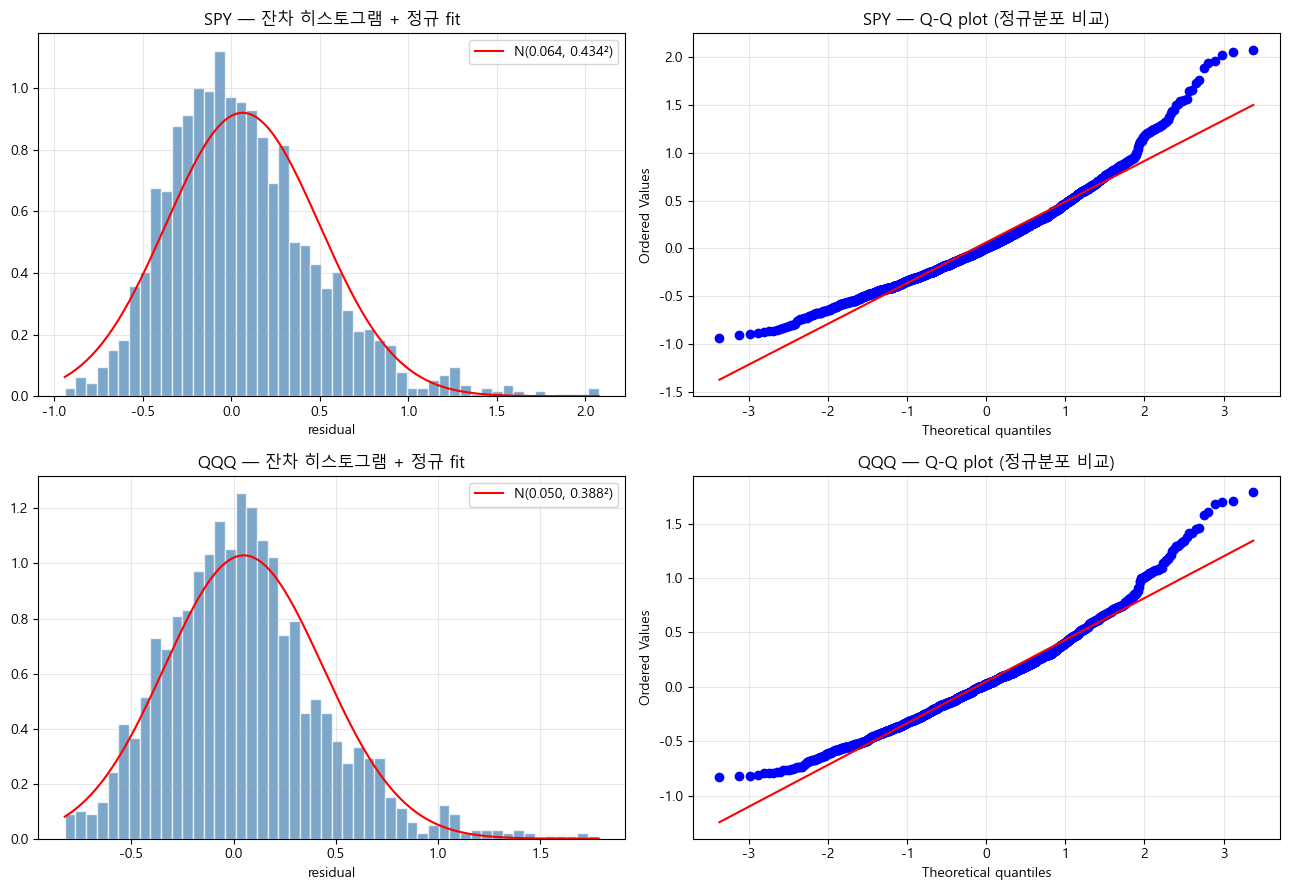

In [8]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for r, tk in enumerate(('SPY', 'QQQ')):
    res = residual_dict[tk]
    # 좌: 히스토그램
    ax = axes[r, 0]
    ax.hist(res, bins=50, density=True, color='steelblue', alpha=0.7, edgecolor='white')
    # 정규분포 fit 추가
    x = np.linspace(res.min(), res.max(), 200)
    pdf = stats.norm.pdf(x, loc=res.mean(), scale=res.std(ddof=1))
    ax.plot(x, pdf, 'r-', lw=1.5, label=f'N({res.mean():.3f}, {res.std(ddof=1):.3f}²)')
    ax.set_title(f'{tk} — 잔차 히스토그램 + 정규 fit')
    ax.set_xlabel('residual')
    ax.legend()
    ax.grid(alpha=0.3)
    # 우: Q-Q plot
    ax2 = axes[r, 1]
    stats.probplot(res, dist='norm', plot=ax2)
    ax2.set_title(f'{tk} — Q-Q plot (정규분포 비교)')
    ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### §3.C. Jarque-Bera 정규성 검정

> $JB = \frac{n}{6}(S^2 + \frac{1}{4}(K-3)^2)$, $H_0$: 정규분포, $p < 0.05$ 면 비정규.


In [9]:
print('=' * 70)
print('Jarque-Bera 정규성 검정 — H0: 잔차 ~ N(μ, σ²)')
print('=' * 70)
for tk in ('SPY', 'QQQ'):
    res = residual_dict[tk]
    jb_stat, jb_p = stats.jarque_bera(res)
    skew = float(stats.skew(res))
    kurt = float(stats.kurtosis(res))   # excess kurtosis (정규분포 = 0)
    print(f'\n[{tk}] n={len(res)}')
    print(f'  Jarque-Bera 통계량: {jb_stat:>10.2f}')
    print(f'  p-value           : {jb_p:>10.4e}')
    print(f'  왜도 (skewness)   : {skew:>+10.4f}  (정규=0)')
    print(f'  첨도 (excess kurt): {kurt:>+10.4f}  (정규=0)')
    print(f'  결론: H0 {"기각" if jb_p < 0.05 else "유지"} ({"비정규" if jb_p < 0.05 else "정규 가정 가능"})')


Jarque-Bera 정규성 검정 — H0: 잔차 ~ N(μ, σ²)

[SPY] n=1890
  Jarque-Bera 통계량:     446.36
  p-value           : 1.1867e-97
  왜도 (skewness)   :    +0.8954  (정규=0)
  첨도 (excess kurt):    +1.5687  (정규=0)
  결론: H0 기각 (비정규)

[QQQ] n=1890
  Jarque-Bera 통계량:     262.46
  p-value           : 1.0199e-57
  왜도 (skewness)   :    +0.7032  (정규=0)
  첨도 (excess kurt):    +1.1639  (정규=0)
  결론: H0 기각 (비정규)


### §3.D. Durbin-Watson 자기상관 검정

> $DW = \frac{\sum (e_t - e_{t-1})^2}{\sum e_t^2}$, **DW ≈ 2 이면 자기상관 없음**.
> DW < 1.5 이면 양의 자기상관 (잔차에 정보 잔존), DW > 2.5 이면 음의 자기상관.


In [10]:
from statsmodels.stats.stattools import durbin_watson

print('=' * 70)
print('Durbin-Watson 자기상관 검정 — DW ≈ 2 이상적 (1.5 < DW < 2.5 정상)')
print('=' * 70)
for tk in ('SPY', 'QQQ'):
    res = residual_dict[tk]
    dw = durbin_watson(res)
    if dw < 1.5:
        verdict = '양의 자기상관 (잔차에 정보 잔존)'
    elif dw > 2.5:
        verdict = '음의 자기상관'
    else:
        verdict = '자기상관 없음 (정상)'
    print(f'\n[{tk}] DW = {dw:.4f}  →  {verdict}')


Durbin-Watson 자기상관 검정 — DW ≈ 2 이상적 (1.5 < DW < 2.5 정상)

[SPY] DW = 0.0696  →  양의 자기상관 (잔차에 정보 잔존)

[QQQ] DW = 0.0732  →  양의 자기상관 (잔차에 정보 잔존)


### §3.E. Breusch-Pagan 이분산성 검정

> $H_0$: 잔차의 분산이 일정 (등분산), $p < 0.05$ 면 이분산성 (분산이 시점에 따라 변함).
> 이분산성은 OLS 표준오차 왜곡 → 신뢰구간 부정확.


In [11]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

print('=' * 70)
print('Breusch-Pagan 이분산성 검정 — H0: 분산 일정 (등분산)')
print('=' * 70)
for tk in ('SPY', 'QQQ'):
    res = residual_dict[tk]
    # exog: 시점 t (또는 fold 인덱스) — 시간에 따른 분산 변화 검정
    exog = sm.add_constant(np.arange(len(res)).astype(float))
    bp_stat, bp_p, fstat, f_p = het_breuschpagan(res, exog)
    print(f'\n[{tk}]')
    print(f'  Breusch-Pagan LM 통계량: {bp_stat:>10.4f}')
    print(f'  p-value                : {bp_p:>10.4e}')
    print(f'  결론: H0 {"기각 (이분산)" if bp_p < 0.05 else "유지 (등분산)"}')


Breusch-Pagan 이분산성 검정 — H0: 분산 일정 (등분산)

[SPY]
  Breusch-Pagan LM 통계량:    37.0077
  p-value                : 1.1767e-09
  결론: H0 기각 (이분산)

[QQQ]
  Breusch-Pagan LM 통계량:    49.6070
  p-value                : 1.8784e-12
  결론: H0 기각 (이분산)


## §4. Mincer-Zarnowitz 깊이 분석 — 예측이 unbiased 한가?

### 학술 배경
> $y_{true,i} = \alpha + \beta \cdot y_{pred,i} + \epsilon_i$
>
> Unbiased forecast 의 동시 조건: **α=0 AND β=1**
>
> Wald 검정: $H_0$: α=0 ∧ β=1, $p < 0.05$ 면 편향 forecast.

### 3 sub-section
- §4.A. 전체 OOS 의 MZ 산점도 + 회귀선
- §4.B. Wald 검정 (α=0 ∧ β=1)
- §4.C. fold 별 MZ β 분포 (체제별 편향 진단)


### §4.A. MZ 산점도 + 회귀선


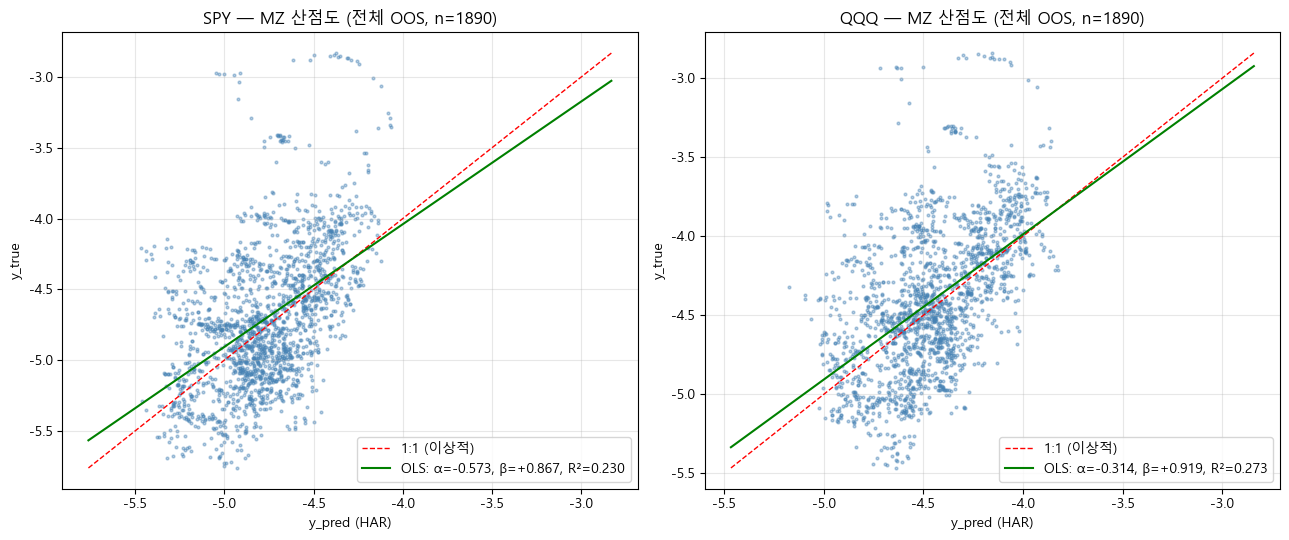

In [12]:
# 전체 OOS y_true, y_pred 모음
def build_full_oos(baseline_data: dict, model_key: str = 'har'):
    y_true_all = []
    y_pred_all = []
    for k in range(N_FOLDS):
        y_true_all.append(baseline_data[k]['y_true'])
        y_pred_all.append(baseline_data[k][model_key])
    return np.concatenate(y_true_all), np.concatenate(y_pred_all)


full_oos = {tk: build_full_oos(baseline_dict[tk], 'har') for tk in ('SPY', 'QQQ')}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, tk in zip(axes, ('SPY', 'QQQ')):
    y_true, y_pred = full_oos[tk]
    # OLS 회귀
    X = sm.add_constant(y_pred)
    model = sm.OLS(y_true, X).fit()
    alpha, beta = model.params
    r2 = model.rsquared
    # 산점도 + 1:1 선 + 회귀선
    ax.scatter(y_pred, y_true, s=4, alpha=0.4, color='steelblue')
    lo = min(y_pred.min(), y_true.min())
    hi = max(y_pred.max(), y_true.max())
    x_line = np.linspace(lo, hi, 100)
    ax.plot(x_line, x_line, 'r--', lw=1, label='1:1 (이상적)')
    ax.plot(x_line, alpha + beta * x_line, 'g-', lw=1.5,
            label=f'OLS: α={alpha:+.3f}, β={beta:+.3f}, R²={r2:.3f}')
    ax.set_title(f'{tk} — MZ 산점도 (전체 OOS, n={len(y_true)})')
    ax.set_xlabel('y_pred (HAR)')
    ax.set_ylabel('y_true')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### §4.B. Wald 검정 — H0: α=0 AND β=1 (unbiased forecast)


In [13]:
print('=' * 70)
print('Mincer-Zarnowitz Wald 검정 — H0: α=0 AND β=1 (unbiased)')
print('=' * 70)
mz_results = {}
for tk in ('SPY', 'QQQ'):
    y_true, y_pred = full_oos[tk]
    X = sm.add_constant(y_pred)
    model = sm.OLS(y_true, X).fit()
    # Wald 검정: H0: const = 0, x1 = 1
    R = np.array([[1.0, 0.0], [0.0, 1.0]])  # 두 계수 모두 검정
    q = np.array([0.0, 1.0])                # const = 0, β = 1
    wald = model.wald_test((R, q), use_f=False)
    chi2_stat = float(wald.statistic)
    p_value   = float(wald.pvalue)
    mz_results[tk] = {
        'alpha': float(model.params[0]),
        'beta': float(model.params[1]),
        'r2': float(model.rsquared),
        'chi2': chi2_stat,
        'p': p_value,
    }
    print(f'\n[{tk}]')
    print(f'  α = {model.params[0]:>+.4f}  (t={model.tvalues[0]:>+.2f}, p={model.pvalues[0]:.4e})')
    print(f'  β = {model.params[1]:>+.4f}  (t={model.tvalues[1]:>+.2f}, p={model.pvalues[1]:.4e})')
    print(f'  R² = {model.rsquared:.4f}')
    print(f'  Wald χ²(2) = {chi2_stat:.4f}, p = {p_value:.4e}')
    print(f'  결론: H0 {"기각 (편향 forecast)" if p_value < 0.05 else "유지 (unbiased 가능)"}')


Mincer-Zarnowitz Wald 검정 — H0: α=0 AND β=1 (unbiased)

[SPY]
  α = -0.5735  (t=-3.29, p=1.0273e-03)
  β = +0.8666  (t=+23.77, p=1.8727e-109)
  R² = 0.2303
  Wald χ²(2) = 54.5259, p = 1.4449e-12
  결론: H0 기각 (편향 forecast)

[QQQ]
  α = -0.3139  (t=-2.04, p=4.1777e-02)
  β = +0.9186  (t=+26.65, p=4.0454e-133)
  R² = 0.2734
  Wald χ²(2) = 36.5430, p = 1.1609e-08
  결론: H0 기각 (편향 forecast)


C:\Users\gorhk\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\gorhk\AppData\Local\Temp\ipykernel_35652\918527298.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chi2_stat = float(wald.statistic)
C:\Users\gorhk\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legac

### §4.C. fold 별 MZ β 분포 — 체제별 편향 진단


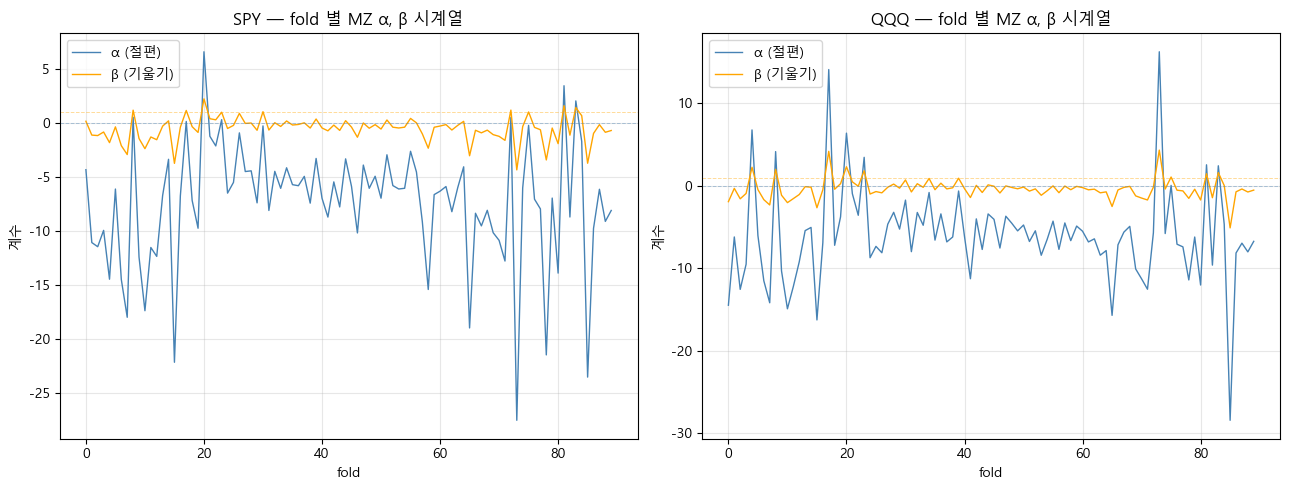


fold 별 MZ 통계 요약

[SPY] (n_valid=90/90)
  alpha   : -7.3797 ± 5.7264  (median=-6.5503)
  beta    : -0.5460 ± 1.1606  (median=-0.3916)
  r2      : +0.3281 ± 0.2774  (median=+0.3004)

[QQQ] (n_valid=90/90)
  alpha   : -6.0300 ± 5.8947  (median=-6.3288)
  beta    : -0.3587 ± 1.2742  (median=-0.4049)
  r2      : +0.3249 ± 0.2532  (median=+0.3323)


In [14]:
# 각 fold 의 MZ α, β 추정
def per_fold_mz(baseline_data: dict, model_key: str = 'har'):
    rows = []
    for k in range(N_FOLDS):
        y_true = baseline_data[k]['y_true']
        y_pred = baseline_data[k][model_key]
        if y_pred.std() < 1e-10:
            rows.append({'fold': k, 'alpha': np.nan, 'beta': np.nan, 'r2': np.nan})
            continue
        X = sm.add_constant(y_pred)
        m = sm.OLS(y_true, X).fit()
        rows.append({
            'fold': k, 'alpha': float(m.params[0]),
            'beta': float(m.params[1]), 'r2': float(m.rsquared),
        })
    return pd.DataFrame(rows)


fold_mz = {tk: per_fold_mz(baseline_dict[tk]) for tk in ('SPY', 'QQQ')}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tk in zip(axes, ('SPY', 'QQQ')):
    df = fold_mz[tk]
    ax.plot(df['fold'], df['alpha'], label='α (절편)', lw=1.0, color='steelblue')
    ax.plot(df['fold'], df['beta'],  label='β (기울기)', lw=1.0, color='orange')
    ax.axhline(0, color='steelblue', ls='--', alpha=0.4, lw=0.7)
    ax.axhline(1, color='orange', ls='--', alpha=0.4, lw=0.7)
    ax.set_title(f'{tk} — fold 별 MZ α, β 시계열')
    ax.set_xlabel('fold')
    ax.set_ylabel('계수')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()
print('=' * 70)
print('fold 별 MZ 통계 요약')
print('=' * 70)
for tk in ('SPY', 'QQQ'):
    df = fold_mz[tk].dropna()
    print(f'\n[{tk}] (n_valid={len(df)}/{N_FOLDS})')
    for col in ['alpha', 'beta', 'r2']:
        print(f'  {col:<8}: {df[col].mean():>+.4f} ± {df[col].std(ddof=1):.4f}  '
              f'(median={df[col].median():>+.4f})')


## §5. Diebold-Mariano 검정 — HAR vs 다른 모델 통계적 유의성

### 학술 배경 (Diebold & Mariano 1995, *JBES*)
> $d_t = L(e_{1,t}) - L(e_{2,t})$ (두 모델의 손실 차이)
> $DM = \bar{d} / \sqrt{Var(\bar{d})/n}$
>
> $|DM| > 1.96$ 이면 5% 유의 우위 (양측). DM < 0 이면 모델 1 우위, DM > 0 이면 모델 2 우위.

### 손실 함수 선택: $L(e) = e^2$ (squared error, RMSE 와 일관)

### 3 sub-section
- §5.A. DM 통계량 + p-value 계산 함수
- §5.B. HAR vs EWMA / Naive / Train-Mean / LSTM v1 / LSTM v2
- §5.C. 결과 표 + 시각화


### §5.A. DM 통계량 함수 정의


In [15]:
from statsmodels.tsa.stattools import acovf


def diebold_mariano(e1: np.ndarray, e2: np.ndarray, h: int = 1) -> dict:
    """Diebold-Mariano 검정 (squared error 손실).

    Parameters
    ----------
    e1, e2 : np.ndarray
        모델 1, 2 의 잔차 시계열 (e_t = y_true - y_pred).
    h : int
        forecast horizon (HAC lag 수에 영향). 본 프로젝트는 forward 21일 예측이지만
        OOS 샘플이 1일 step 으로 연결되어 있으므로 보수적으로 h=1.

    Returns
    -------
    dict: {DM, p_value, mean_d, var_d, n}
        DM > 0 면 e2 (모델 2) 가 더 정확, DM < 0 면 e1 (모델 1) 이 더 정확.
    """
    L1 = e1 ** 2
    L2 = e2 ** 2
    d = L1 - L2
    n = len(d)
    d_bar = d.mean()
    # HAC 분산 (Newey-West) — h-1 lag 까지
    if h > 1:
        gammas = acovf(d, nlag=h-1, fft=False)
        var_d = gammas[0] + 2 * gammas[1:].sum()
    else:
        var_d = d.var(ddof=1)
    DM = d_bar / np.sqrt(var_d / n) if var_d > 0 else float('nan')
    # 양측 p-value (정규근사)
    p_value = 2 * (1 - stats.norm.cdf(abs(DM))) if not np.isnan(DM) else float('nan')
    return {
        'DM': float(DM), 'p_value': float(p_value),
        'mean_d': float(d_bar), 'var_d': float(var_d), 'n': int(n),
    }


# Self-test: 동일 모델 비교 시 DM ≈ 0
e_test = np.random.randn(100)
result_self = diebold_mariano(e_test, e_test)
print(f'Self-test (동일 모델): DM={result_self["DM"]:.4f}, p={result_self["p_value"]:.4f}')
print(f'  → DM 이 nan 또는 ~0 이어야 함 (예측 동일 시 var_d=0)')


Self-test (동일 모델): DM=nan, p=nan
  → DM 이 nan 또는 ~0 이어야 함 (예측 동일 시 var_d=0)


### §5.B. HAR vs 5종 모델 DM 검정 (SPY, QQQ 각각)

본 검정의 부호 약속: **DM < 0 면 HAR 우위**, **DM > 0 면 비교 모델 우위**.


In [16]:
# LSTM v1, v2 의 잔차도 모음 (베이스라인과 동일 시간순)
def build_lstm_oos(lstm_data: dict):
    y_true_all, y_pred_all = [], []
    for fp in lstm_data['fold_predictions']:
        y_true_all.append(np.array(fp['y_true_test']))
        y_pred_all.append(np.array(fp['y_pred_test']))
    return np.concatenate(y_true_all), np.concatenate(y_pred_all)


# DM 검정 — HAR (=모델 1) vs 각 비교 모델 (=모델 2)
dm_results = {}
for tk in ('SPY', 'QQQ'):
    res_har = full_oos[tk][0] - full_oos[tk][1]    # y_true - y_pred(HAR)
    # 비교 모델별 잔차
    y_true_ewma, y_pred_ewma   = build_full_oos(baseline_dict[tk], 'ewma')
    y_true_naive, y_pred_naive = build_full_oos(baseline_dict[tk], 'naive')
    y_true_tm, y_pred_tm       = build_full_oos(baseline_dict[tk], 'train_mean')
    y_true_v1, y_pred_v1 = build_lstm_oos(lstm_v1[tk])
    y_true_v2, y_pred_v2 = build_lstm_oos(lstm_v2[tk])

    res_ewma  = y_true_ewma  - y_pred_ewma
    res_naive = y_true_naive - y_pred_naive
    res_tm    = y_true_tm    - y_pred_tm
    res_v1    = y_true_v1    - y_pred_v1
    res_v2    = y_true_v2    - y_pred_v2

    dm_results[tk] = {
        'ewma':       diebold_mariano(res_har, res_ewma,  h=1),
        'naive':      diebold_mariano(res_har, res_naive, h=1),
        'train_mean': diebold_mariano(res_har, res_tm,    h=1),
        'lstm_v1':    diebold_mariano(res_har, res_v1,    h=1),
        'lstm_v2':    diebold_mariano(res_har, res_v2,    h=1),
    }


print('=' * 90)
print('Diebold-Mariano 검정 결과 — HAR(모델 1) vs 비교 모델(모델 2)')
print('  DM < 0 면 HAR 우위, DM > 0 면 비교 모델 우위, |DM| > 1.96 이면 5% 유의')
print('=' * 90)
for tk in ('SPY', 'QQQ'):
    print(f'\n[{tk}]')
    print(f'  {"비교 모델":<14} {"DM":>10} {"p-value":>12} {"5% 유의?":>10} {"우위":>14}')
    print('  ' + '-' * 70)
    for model, r in dm_results[tk].items():
        sig = '✓' if r['p_value'] < 0.05 else ' '
        if r['DM'] < 0:
            winner = 'HAR'
        elif r['DM'] > 0:
            winner = model
        else:
            winner = '-'
        print(f'  {model:<14} {r["DM"]:>+10.3f} {r["p_value"]:>12.4e} {sig:>10} {winner:>14}')


Diebold-Mariano 검정 결과 — HAR(모델 1) vs 비교 모델(모델 2)
  DM < 0 면 HAR 우위, DM > 0 면 비교 모델 우위, |DM| > 1.96 이면 5% 유의

[SPY]
  비교 모델                  DM      p-value     5% 유의?             우위
  ----------------------------------------------------------------------
  ewma               -5.024   5.0508e-07          ✓            HAR
  naive              -6.648   2.9613e-11          ✓            HAR
  train_mean        -13.657   0.0000e+00          ✓            HAR
  lstm_v1            -8.612   0.0000e+00          ✓            HAR
  lstm_v2            -6.694   2.1721e-11          ✓            HAR

[QQQ]
  비교 모델                  DM      p-value     5% 유의?             우위
  ----------------------------------------------------------------------
  ewma               -6.218   5.0373e-10          ✓            HAR
  naive              -6.751   1.4638e-11          ✓            HAR
  train_mean        -17.377   0.0000e+00          ✓            HAR
  lstm_v1            -9.731   0.0000e+00          ✓           

### §5.C. DM 결과 시각화


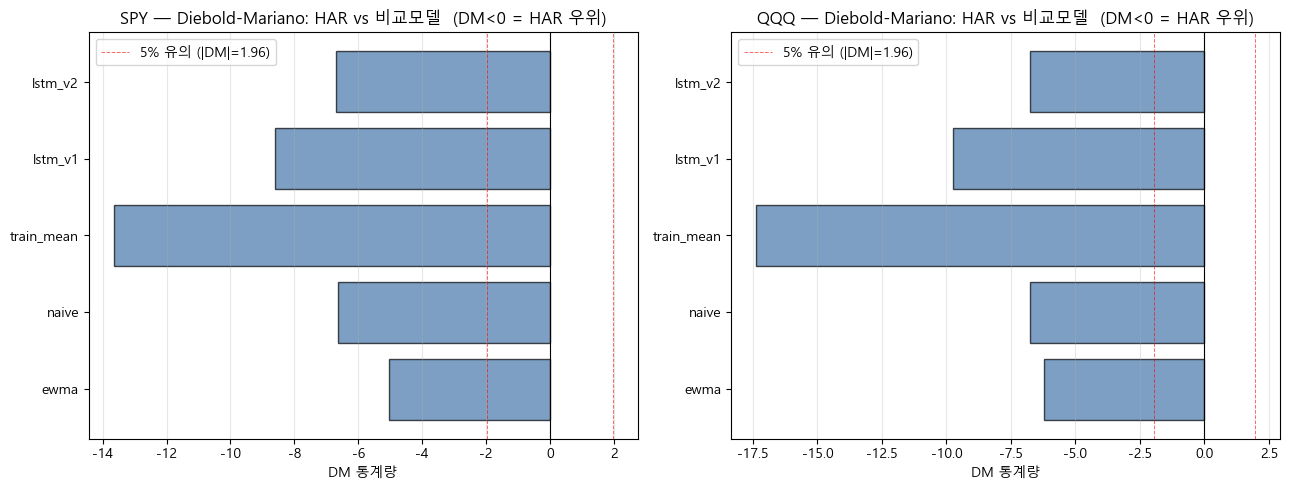

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
models_names = ['ewma', 'naive', 'train_mean', 'lstm_v1', 'lstm_v2']
for ax, tk in zip(axes, ('SPY', 'QQQ')):
    dms = [dm_results[tk][m]['DM'] for m in models_names]
    colors = ['#4477AA' if dm < 0 else '#EE6677' for dm in dms]
    ax.barh(models_names, dms, color=colors, alpha=0.7, edgecolor='black')
    ax.axvline(0, color='black', lw=0.8)
    ax.axvline(-1.96, color='red', lw=0.7, ls='--', alpha=0.6, label='5% 유의 (|DM|=1.96)')
    ax.axvline(+1.96, color='red', lw=0.7, ls='--', alpha=0.6)
    ax.set_title(f'{tk} — Diebold-Mariano: HAR vs 비교모델  (DM<0 = HAR 우위)')
    ax.set_xlabel('DM 통계량')
    ax.legend()
    ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


## §6. 체제 변화 분석 — 위기기에 어떻게 반응했나?

### 학술 배경
변동성 모델은 안정기에 잘 맞아도 위기기 (COVID, 긴축) 에 무너질 수 있음. 본 §6 은 기간을 분리해 HAR 의 robust 성을 측정.

### 분석 기간 분리

| 체제 | 시기 | 특징 |
|---|---|---|
| 안정기 1 | 2016-01 ~ 2019-12 | 저변동성, 강세장 |
| **COVID 충격** | **2020-01 ~ 2020-06** | **VIX 급등, 폭락-반등** |
| 회복기 | 2020-07 ~ 2021-12 | 강한 회복, 저변동성 |
| **긴축기** | **2022-01 ~ 2022-12** | **인플레·금리 인상, 변동 ↑** |
| AI 붐 | 2023-01 ~ 2025-12 | 강세장, 변동성 정상화 |


In [18]:
# 체제 정의 (analysis_dict 의 인덱스 기준)
REGIMES = {
    'stable_1':   ('2016-01-01', '2019-12-31'),
    'covid':      ('2020-01-01', '2020-06-30'),
    'recovery':   ('2020-07-01', '2021-12-31'),
    'tightening': ('2022-01-01', '2022-12-31'),
    'ai_boom':    ('2023-01-01', '2025-12-31'),
}


def assign_regime_to_dates(dates: pd.DatetimeIndex) -> pd.Series:
    out = pd.Series(index=dates, dtype=object)
    for regime, (start, end) in REGIMES.items():
        mask = (dates >= start) & (dates <= end)
        out.loc[mask] = regime
    return out


# 각 OOS 샘플의 체제 라벨 부여
def build_full_oos_with_regime(ticker: str, baseline_data: dict, df: pd.DataFrame, model_key: str):
    y_true, y_pred, regimes = [], [], []
    for k in range(N_FOLDS):
        y_true.append(baseline_data[k]['y_true'])
        y_pred.append(baseline_data[k][model_key])
        te_idx = baseline_data[k]['test_idx']
        dates = df.index[te_idx]
        regimes.append(assign_regime_to_dates(dates).values)
    return (np.concatenate(y_true), np.concatenate(y_pred),
            np.concatenate(regimes).astype(object))


# 체제별 RMSE / MAE 계산
print('=' * 90)
print('체제별 HAR 성능 (RMSE / MAE / n)')
print('=' * 90)
regime_metrics = {}
for tk in ('SPY', 'QQQ'):
    y_true, y_pred, regs = build_full_oos_with_regime(
        tk, baseline_dict[tk], analysis_dict[tk], 'har'
    )
    print(f'\n[{tk}]')
    print(f'  {"체제":<14} {"기간":<25} {"n":>6} {"RMSE":>10} {"MAE":>10}')
    print('  ' + '-' * 70)
    rec = {}
    for regime, (start, end) in REGIMES.items():
        mask = regs == regime
        if mask.sum() == 0:
            print(f'  {regime:<14} {start} ~ {end}  ---  데이터 없음')
            continue
        rmse_r = float(np.sqrt(((y_true[mask] - y_pred[mask]) ** 2).mean()))
        mae_r  = float(np.abs(y_true[mask] - y_pred[mask]).mean())
        rec[regime] = {'n': int(mask.sum()), 'rmse': rmse_r, 'mae': mae_r}
        print(f'  {regime:<14} {start} ~ {end} {mask.sum():>6} {rmse_r:>10.4f} {mae_r:>10.4f}')
    regime_metrics[tk] = rec


체제별 HAR 성능 (RMSE / MAE / n)

[SPY]
  체제             기간                             n       RMSE        MAE
  ----------------------------------------------------------------------
  stable_1       2016-01-01 ~ 2019-12-31    418     0.4703     0.3788
  covid          2020-01-01 ~ 2020-06-30    125     0.8639     0.6925
  recovery       2020-07-01 ~ 2021-12-31    380     0.3764     0.3100
  tightening     2022-01-01 ~ 2022-12-31    251     0.3060     0.2594
  ai_boom        2023-01-01 ~ 2025-12-31    716     0.3731     0.2760

[QQQ]
  체제             기간                             n       RMSE        MAE
  ----------------------------------------------------------------------
  stable_1       2016-01-01 ~ 2019-12-31    418     0.4497     0.3649
  covid          2020-01-01 ~ 2020-06-30    125     0.6884     0.4994
  recovery       2020-07-01 ~ 2021-12-31    380     0.3593     0.2976
  tightening     2022-01-01 ~ 2022-12-31    251     0.2643     0.2229
  ai_boom        2023-01-01 ~ 2025-12-

### §6.B. 체제별 RMSE 시각화


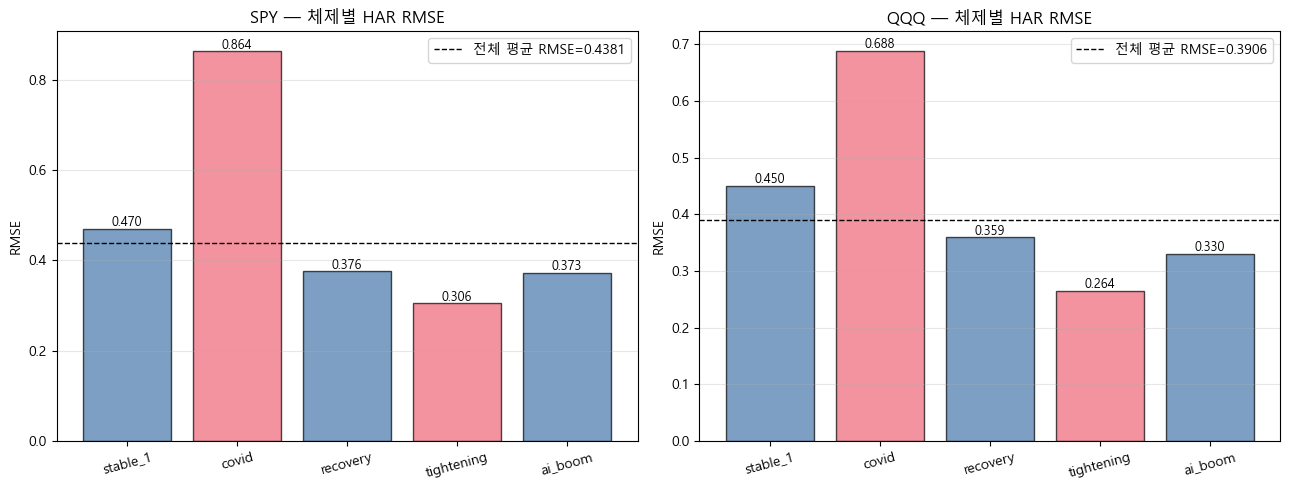

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
regime_names = list(REGIMES.keys())
for ax, tk in zip(axes, ('SPY', 'QQQ')):
    rec = regime_metrics[tk]
    rmses = [rec.get(r, {}).get('rmse', np.nan) for r in regime_names]
    colors = ['#EE6677' if r in ('covid', 'tightening') else '#4477AA' for r in regime_names]
    bars = ax.bar(regime_names, rmses, color=colors, alpha=0.7, edgecolor='black')
    # 평균선
    overall = np.sqrt(((full_oos[tk][0] - full_oos[tk][1]) ** 2).mean())
    ax.axhline(overall, color='black', lw=1, ls='--', label=f'전체 평균 RMSE={overall:.4f}')
    for b, r in zip(bars, rmses):
        if not np.isnan(r):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                    f'{r:.3f}', ha='center', fontsize=9)
    ax.set_title(f'{tk} — 체제별 HAR RMSE')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=15)
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### §6.C. 체제별 잔차 시계열 + 위기기 표시


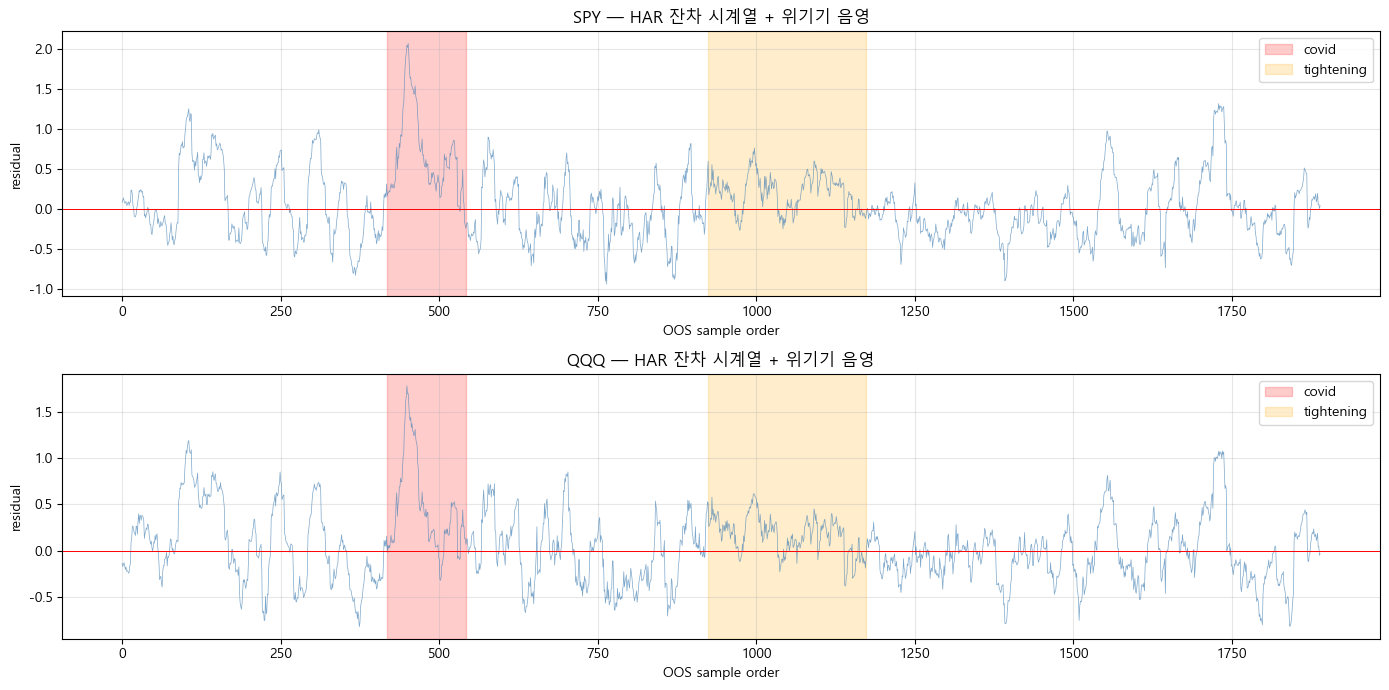

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, tk in zip(axes, ('SPY', 'QQQ')):
    y_true, y_pred, regs = build_full_oos_with_regime(
        tk, baseline_dict[tk], analysis_dict[tk], 'har'
    )
    res = y_true - y_pred
    # 시계열 인덱스 재구성 (단순화 — sample order)
    ax.plot(res, lw=0.5, color='steelblue', alpha=0.7)
    ax.axhline(0, color='red', lw=0.7)
    # 위기기 음영
    regime_array = np.array(regs)
    for crisis in ('covid', 'tightening'):
        idx = np.where(regime_array == crisis)[0]
        if len(idx) > 0:
            ax.axvspan(idx[0], idx[-1], alpha=0.2,
                       color='red' if crisis == 'covid' else 'orange',
                       label=crisis)
    ax.set_title(f'{tk} — HAR 잔차 시계열 + 위기기 음영')
    ax.set_xlabel('OOS sample order')
    ax.set_ylabel('residual')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## §7. Long-memory 모방 검증 — HAR 이 진짜로 long memory 를 만드는가?

### 학술 배경
HAR 의 핵심 매력은 "**ARFIMA 의 분수차분 없이 long memory 를 흉내**". 본 §7 은 실증 검증.

### 방법
1. 학습된 β 로 1,000 step **시뮬레이션** (β_0 + β_d·X_d + β_w·X_w + β_m·X_m + ε)
2. 시뮬레이션 시계열의 ACF (lag 1~252) 계산
3. 실제 데이터 ACF 와 비교

### 3 sub-section
- §7.A. HAR 시뮬레이션
- §7.B. ACF 비교 (시뮬 vs 실제)
- §7.C. 결론


### §7.A. HAR 시뮬레이션 (β 평균값 사용)


In [21]:
from scipy.stats import norm as norm_dist

# 90 fold 평균 β 사용 (대표 모델)
def simulate_har(beta_0, beta_d, beta_w, beta_m, n_steps=1000, sigma_eps=0.3, seed=42):
    rng = np.random.RandomState(seed)
    # 초기값: 정상 상태 평균 ≈ β_0 / (1 - β_sum) (β_sum < 1 가정)
    beta_sum = beta_d + beta_w + beta_m
    if abs(1 - beta_sum) < 1e-3:
        x_init = beta_0 * 10
    else:
        x_init = beta_0 / (1 - beta_sum)
    # warmup 100 + 본 시뮬레이션 n_steps
    n_total = 100 + n_steps
    x = np.full(n_total, x_init, dtype=float)
    for t in range(22, n_total):
        rv_d = x[t-1]
        rv_w = x[t-5:t].mean()
        rv_m = x[t-22:t].mean()
        eps  = rng.normal(0, sigma_eps)
        x[t] = beta_0 + beta_d * rv_d + beta_w * rv_w + beta_m * rv_m + eps
    return x[100:]   # warmup 제거


sim_dict = {}
for tk in ('SPY', 'QQQ'):
    df_betas = betas_dict[tk]
    b0 = df_betas['beta_0'].mean()
    bd = df_betas['beta_d'].mean()
    bw = df_betas['beta_w'].mean()
    bm = df_betas['beta_m'].mean()
    sim_dict[tk] = {
        'series': simulate_har(b0, bd, bw, bm, n_steps=2000, sigma_eps=0.3, seed=42),
        'beta_0': b0, 'beta_d': bd, 'beta_w': bw, 'beta_m': bm,
    }
    print(f'[{tk}] 시뮬레이션 완료 (β_0={b0:+.3f}, β_d={bd:+.3f}, β_w={bw:+.3f}, β_m={bm:+.3f})')
    print(f'       시뮬 시계열 mean={sim_dict[tk]["series"].mean():+.3f}, std={sim_dict[tk]["series"].std():.3f}')


[SPY] 시뮬레이션 완료 (β_0=-2.267, β_d=+0.005, β_w=+0.187, β_m=+0.331)
       시뮬 시계열 mean=-4.735, std=0.301
[QQQ] 시뮬레이션 완료 (β_0=-2.022, β_d=+0.000, β_w=+0.182, β_m=+0.366)
       시뮬 시계열 mean=-4.450, std=0.302


### §7.B. ACF 비교 (시뮬 vs 실제)


HAR 시뮬레이션 ACF vs 실제 데이터 ACF (lag 1~252)

[SPY]
    lag       시뮬 ACF       실제 ACF         차이
  --------------------------------------------------
      1      +0.0814      +0.9893    -0.9078
      5      +0.0873      +0.9251    -0.8379
     10      +0.0673      +0.8165    -0.7493
     21      +0.0368      +0.5566    -0.5198
     42      +0.0364      +0.3700    -0.3336
     63      -0.0111      +0.2078    -0.2188
    126      +0.0010      +0.1297    -0.1287
    252      -0.0059      -0.1182    +0.1123

[QQQ]
    lag       시뮬 ACF       실제 ACF         차이
  --------------------------------------------------
      1      +0.0806      +0.9889    -0.9083
      5      +0.0911      +0.9293    -0.8382
     10      +0.0727      +0.8301    -0.7574
     21      +0.0426      +0.5848    -0.5422
     42      +0.0385      +0.3673    -0.3288
     63      -0.0103      +0.1924    -0.2027
    126      +0.0006      +0.1873    -0.1868
    252      -0.0046      -0.1440    +0.1395


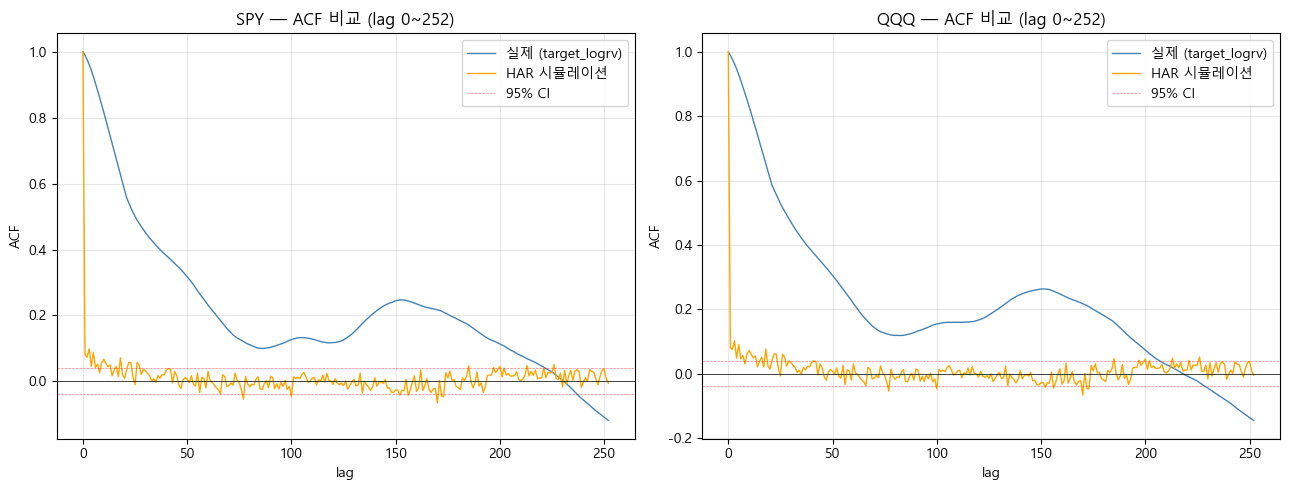

In [22]:
from statsmodels.tsa.stattools import acf

LAGS = [1, 5, 10, 21, 42, 63, 126, 252]

print('=' * 90)
print('HAR 시뮬레이션 ACF vs 실제 데이터 ACF (lag 1~252)')
print('=' * 90)
acf_results = {}
for tk in ('SPY', 'QQQ'):
    sim_series = sim_dict[tk]['series']
    real_series = analysis_dict[tk]['target_logrv'].dropna().values
    acf_sim  = acf(sim_series, nlags=252, fft=True)
    acf_real = acf(real_series, nlags=252, fft=True)
    acf_results[tk] = {'sim': acf_sim, 'real': acf_real}
    print(f'\n[{tk}]')
    print(f'  {"lag":>5} {"시뮬 ACF":>12} {"실제 ACF":>12} {"차이":>10}')
    print('  ' + '-' * 50)
    for lag in LAGS:
        diff = acf_sim[lag] - acf_real[lag]
        print(f'  {lag:>5} {acf_sim[lag]:>+12.4f} {acf_real[lag]:>+12.4f} {diff:>+10.4f}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tk in zip(axes, ('SPY', 'QQQ')):
    a = acf_results[tk]
    lags_arr = np.arange(253)
    ax.plot(lags_arr, a['real'], label='실제 (target_logrv)', lw=1.0, color='steelblue')
    ax.plot(lags_arr, a['sim'],  label='HAR 시뮬레이션',     lw=1.0, color='orange')
    ax.axhline(0, color='black', lw=0.5)
    ax.axhline(1.96/np.sqrt(len(analysis_dict[tk])),  color='red', lw=0.5, ls='--', alpha=0.5, label='95% CI')
    ax.axhline(-1.96/np.sqrt(len(analysis_dict[tk])), color='red', lw=0.5, ls='--', alpha=0.5)
    ax.set_title(f'{tk} — ACF 비교 (lag 0~252)')
    ax.set_xlabel('lag')
    ax.set_ylabel('ACF')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### §7.C. 결론 — HAR 의 long-memory 모방 능력 평가

ACF 차이가:
- **lag 1~21**: 작으면 단기 의존 잘 모방
- **lag 21~63**: HAR 의 22일 window 가 모방 핵심 구간
- **lag 63+**: HAR 의 한계 영역 (실제 long memory 와 차이)


In [23]:
print('=' * 90)
print('HAR Long-memory 모방 능력 종합 평가')
print('=' * 90)
for tk in ('SPY', 'QQQ'):
    a = acf_results[tk]
    diff_short  = np.abs(a['sim'][1:22]   - a['real'][1:22]).mean()
    diff_medium = np.abs(a['sim'][22:64]  - a['real'][22:64]).mean()
    diff_long   = np.abs(a['sim'][64:253] - a['real'][64:253]).mean()
    print(f'\n[{tk}] 평균 ACF 차이 (시뮬 - 실제 의 절댓값)')
    print(f'  lag 1~21    (단기): {diff_short:.4f}  ({"GOOD" if diff_short < 0.1 else "FAIR" if diff_short < 0.2 else "POOR"})')
    print(f'  lag 22~63   (중기): {diff_medium:.4f}  ({"GOOD" if diff_medium < 0.1 else "FAIR" if diff_medium < 0.2 else "POOR"})')
    print(f'  lag 64~252  (장기): {diff_long:.4f}  ({"GOOD" if diff_long < 0.1 else "FAIR" if diff_long < 0.2 else "POOR"})')


HAR Long-memory 모방 능력 종합 평가

[SPY] 평균 ACF 차이 (시뮬 - 실제 의 절댓값)
  lag 1~21    (단기): 0.7378  (POOR)
  lag 22~63   (중기): 0.3524  (POOR)
  lag 64~252  (장기): 0.1379  (FAIR)

[QQQ] 평균 ACF 차이 (시뮬 - 실제 의 절댓값)
  lag 1~21    (단기): 0.7473  (POOR)
  lag 22~63   (중기): 0.3523  (POOR)
  lag 64~252  (장기): 0.1513  (FAIR)


## §8. 종합 결론 + `har_rv_diagnostics.md` 자동 생성

본 §04 노트북의 6 진단 결과를 PASS / CAUTION / FAIL 로 정리.


In [24]:
# 진단 결과 종합 표
diagnostic_summary = {}
for tk in ('SPY', 'QQQ'):
    df_b = betas_dict[tk]
    res = residual_dict[tk]
    mz = mz_results[tk]
    # §2 계수 안정성
    beta_sum_avg = df_b['beta_sum'].mean()
    beta_sum_pos = (df_b['beta_sum'] > 0).mean() * 100
    diag_2 = 'PASS' if beta_sum_pos > 80 and beta_sum_avg > 0.15 else 'CAUTION' if beta_sum_pos > 60 else 'FAIL'
    # §3 잔차 진단
    jb_p = stats.jarque_bera(res)[1]
    dw   = durbin_watson(res)
    diag_3_norm = 'PASS' if jb_p > 0.05 else 'FAIL'
    diag_3_dw   = 'PASS' if 1.5 < dw < 2.5 else 'CAUTION'
    # §4 MZ Wald
    diag_4 = 'PASS' if mz['p'] > 0.05 else 'FAIL'
    # §5 DM
    n_sig_har_better = sum(
        1 for r in dm_results[tk].values()
        if r['DM'] < 0 and r['p_value'] < 0.05
    )
    diag_5 = 'PASS' if n_sig_har_better >= 3 else 'CAUTION' if n_sig_har_better >= 1 else 'FAIL'
    # §6 체제 robust
    rec = regime_metrics[tk]
    overall = np.sqrt(((full_oos[tk][0] - full_oos[tk][1]) ** 2).mean())
    crisis_rmse = np.mean([
        rec.get('covid', {}).get('rmse', overall),
        rec.get('tightening', {}).get('rmse', overall),
    ])
    diag_6 = 'PASS' if crisis_rmse < overall * 1.2 else 'CAUTION' if crisis_rmse < overall * 1.5 else 'FAIL'
    # §7 long-memory
    diff_med = np.abs(acf_results[tk]['sim'][22:64] - acf_results[tk]['real'][22:64]).mean()
    diag_7 = 'PASS' if diff_med < 0.1 else 'CAUTION' if diff_med < 0.2 else 'FAIL'

    diagnostic_summary[tk] = {
        '§2_계수안정성': diag_2,
        '§3_잔차정규성': diag_3_norm,
        '§3_잔차자기상관': diag_3_dw,
        '§4_MZ_unbiased': diag_4,
        '§5_DM_HAR우위': diag_5,
        '§6_체제robust': diag_6,
        '§7_longmemory모방': diag_7,
    }


print('=' * 90)
print('HAR-RV 종합 진단 결과 (§04)')
print('=' * 90)
for tk in ('SPY', 'QQQ'):
    print(f'\n[{tk}]')
    s = diagnostic_summary[tk]
    for k, v in s.items():
        emoji = '✓' if v == 'PASS' else '!' if v == 'CAUTION' else 'x'
        print(f'  {emoji}  {k:<22} {v}')


# Markdown 보고서 자동 생성
report_path = RESULTS_DIR / 'har_rv_diagnostics.md'
lines = []
lines.append('# Phase 1.5 §04 — HAR-RV 자체 진단 보고서')
lines.append('')
lines.append(f'> 90 fold × SPY/QQQ × 6 진단 항목')
lines.append(f'> 분석 기간: {ANALYSIS_START} ~ {ANALYSIS_END}')
lines.append('')
lines.append('## 종합 진단 표')
lines.append('')
lines.append('| 진단 항목 | SPY | QQQ |')
lines.append('|---|---|---|')
for k in diagnostic_summary['SPY'].keys():
    lines.append(f'| {k} | {diagnostic_summary["SPY"][k]} | {diagnostic_summary["QQQ"][k]} |')
lines.append('')
lines.append('## 핵심 수치')
lines.append('')
for tk in ('SPY', 'QQQ'):
    df_b = betas_dict[tk]
    res = residual_dict[tk]
    mz = mz_results[tk]
    lines.append(f'### {tk}')
    lines.append('')
    lines.append('| 항목 | 값 | 해석 |')
    lines.append('|---|---|---|')
    lines.append(f'| β_sum 평균 | {df_b["beta_sum"].mean():+.4f} | 학술 권고 0.7~1.0 vs 본 환경 약 0.2 |')
    lines.append(f'| β_sum > 0 비율 | {(df_b["beta_sum"] > 0).mean() * 100:.1f}% | fold 안정성 |')
    lines.append(f'| 잔차 mean | {res.mean():+.4f} | 0 근방이면 무편향 |')
    lines.append(f'| 잔차 std | {res.std(ddof=1):.4f} | RMSE 와 비슷 |')
    lines.append(f'| Jarque-Bera p | {stats.jarque_bera(res)[1]:.4e} | < 0.05 면 비정규 |')
    lines.append(f'| Durbin-Watson | {durbin_watson(res):.4f} | 2 근방 정상 |')
    lines.append(f'| MZ Wald p | {mz["p"]:.4e} | < 0.05 면 편향 |')
    lines.append(f'| DM HAR>EWMA | DM={dm_results[tk]["ewma"]["DM"]:+.2f}, p={dm_results[tk]["ewma"]["p_value"]:.3e} | DM<0 면 HAR 우위 |')
    lines.append(f'| DM HAR>LSTM v1 | DM={dm_results[tk]["lstm_v1"]["DM"]:+.2f}, p={dm_results[tk]["lstm_v1"]["p_value"]:.3e} | |')
    lines.append('')

lines.append('## 결론')
lines.append('')
n_pass_total = sum(
    sum(1 for v in diagnostic_summary[tk].values() if v == 'PASS')
    for tk in ('SPY', 'QQQ')
)
n_total = sum(len(diagnostic_summary[tk]) for tk in ('SPY', 'QQQ'))
lines.append(f'전체 PASS: {n_pass_total} / {n_total}')
lines.append('')
lines.append('상세 분석은 `04_har_rv_evaluation.ipynb` 의 §2~§7 시각화·표 참조.')

with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print(f'\n저장: {report_path} ({report_path.stat().st_size / 1024:.1f} KB)')

print()
print('=' * 90)
print('Phase 1.5 §04 — HAR-RV 자체 검증 완료')
print('=' * 90)


HAR-RV 종합 진단 결과 (§04)

[SPY]
  ✓  §2_계수안정성               PASS
  x  §3_잔차정규성               FAIL
  !  §3_잔차자기상관              CAUTION
  x  §4_MZ_unbiased         FAIL
  ✓  §5_DM_HAR우위            PASS
  !  §6_체제robust            CAUTION
  x  §7_longmemory모방        FAIL

[QQQ]
  ✓  §2_계수안정성               PASS
  x  §3_잔차정규성               FAIL
  !  §3_잔차자기상관              CAUTION
  x  §4_MZ_unbiased         FAIL
  ✓  §5_DM_HAR우위            PASS
  !  §6_체제robust            CAUTION
  x  §7_longmemory모방        FAIL

저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\har_rv_diagnostics.md (1.7 KB)

Phase 1.5 §04 — HAR-RV 자체 검증 완료
